In [1]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

In [2]:
arima_process = ArmaProcess(ar = [1, -0.6, 0.3], ma=[1, 0.4, -0.3])

In [3]:
arima_process.isstationary

True

In [4]:
arima_process.arroots

array([1.-1.52752523j, 1.+1.52752523j])

In [5]:
np.abs(arima_process.arroots)

array([1.82574186, 1.82574186])

In [6]:
arima_process.isinvertible

True

In [7]:
arima_process.maroots

array([-1.27698396,  2.6103173 ])

In [8]:
np.abs(arima_process.maroots)

array([1.27698396, 2.6103173 ])

3.1.1

In [9]:
arima_process = ArmaProcess(ar = [1, 0.8, -0.7], ma=[1, 0.5, -0.8])

In [10]:
arima_process.isstationary

False

In [11]:
arima_process.isinvertible

False

In [12]:
arima_process = ArmaProcess(ar = [1, -0.2, 0.08], ma=[1, -0.3, -0.88])

In [13]:
arima_process.isstationary

True

In [14]:
arima_process.isinvertible

False

In [15]:
import pandas as pd

from statsmodels.tsa.api import ARIMA
from statsmodels.stats.api import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_predict

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [16]:
y = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01', end='2023-12-31')

In [17]:
# спецификация модели
mod = ARIMA(y, order=(2,2,1), trend=[0,0,1], missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                WGS10YR   No. Observations:                 1252
Model:                 ARIMA(2, 2, 1)   Log Likelihood                1129.538
Date:                Wed, 04 Mar 2026   AIC                          -2249.076
Time:                        19:48:13   BIC                          -2223.421
Sample:                    01-07-2000   HQIC                         -2239.432
                         - 12-29-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          3.309e-06   7.11e-06      0.465      0.642   -1.06e-05    1.73e-05
ar.L1          0.2408      0.023     10.268      0.000       0.195       0.287
ar.L2          0.0081      0.023      0.359      0.719      -0.036       0.053
ma.L1         -0.9985      0.007   -144.723      0.000      -1.012      -0.985
sigma2         0.0096      0.000     31.471      0.000       0.009       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.34   Jarque-Bera (JB):                94.45
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                             0.03
Prob(H) (two-sided):                  0.21   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [18]:
forecasts = res.forecast(steps=10)
forecasts

2024-01-05    3.836844
2024-01-12    3.835705
2024-01-19    3.837847
2024-01-26    3.840881
2024-02-02    3.844161
2024-02-09    3.847514
2024-02-16    3.850890
2024-02-23    3.854278
2024-03-01    3.857674
2024-03-08    3.861077
Freq: W-FRI, Name: predicted_mean, dtype: float64

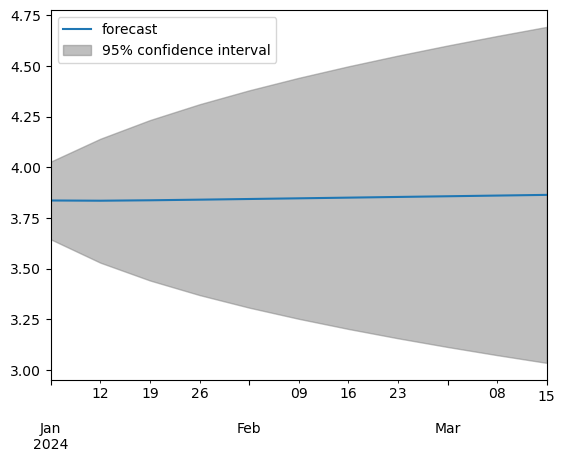

In [19]:
plot_predict(res, start=len(y), end=len(y)+10, alpha=0.05)

plt.show()

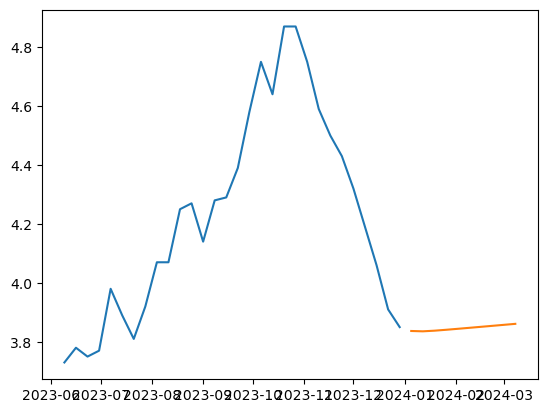

In [20]:
plt.plot(y.tail(30))
plt.plot(forecasts)

plt.show()

In [21]:
gdp = web.DataReader(name='GDP', data_source='fred', start='1995-01')
y = np.log(gdp)
y

,GDP
DATE,
1995-01-01,8.925626
1995-04-01,8.933400
1995-07-01,8.946782
1995-10-01,8.958358
1996-01-01,8.970619
...,...
2024-10-01,10.303108
2025-01-01,10.310355
2025-04-01,10.325014


In [22]:
# спецификация модели
mod1 = ARIMA(y, order=(1,0,1), trend='ct', missing='drop')
# подгонка модели на данных
res1 = mod1.fit()
# выводим результаты подгонки
res1.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    GDP   No. Observations:                  124
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 362.044
Date:                Wed, 04 Mar 2026   AIC                           -714.088
Time:                        19:48:14   BIC                           -699.987
Sample:                    01-01-1995   HQIC                          -708.360
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.9320      0.117     76.537      0.000       8.703       9.161
x1             0.0112      0.001      8.248      0.000       0.009       0.014
ar.L1          0.9594      0.042     22.842      0.000       0.877       1.042
ma.L1         -0.0363      0.071     -0.511      0.610      -0.176       0.103
sigma2         0.0002    8.1e-06     20.614      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5659.79
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):              11.70   Skew:                            -3.16
Prob(H) (two-sided):                  0.00   Kurtosis:                        35.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
# спецификация модели
mod2 = ARIMA(y, order=(1,1,0), trend=[0,1], missing='drop')
# подгонка модели на данных
res2 = mod2.fit()
# выводим результаты подгонки
res2.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    GDP   No. Observations:                  124
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 359.128
Date:                Wed, 04 Mar 2026   AIC                           -712.256
Time:                        19:48:14   BIC                           -703.820
Sample:                    01-01-1995   HQIC                          -708.829
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0116      0.002      6.050      0.000       0.008       0.015
ar.L1         -0.0695      0.039     -1.798      0.072      -0.145       0.006
sigma2         0.0002   7.42e-06     22.943      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4700.62
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):              14.23   Skew:                            -2.64
Prob(H) (two-sided):                  0.00   Kurtosis:                        32.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
# спецификация модели
mod3 = ARIMA(y, order=(1,1,1), trend=[0,0], missing='drop')
# подгонка модели на данных
res3 = mod3.fit()
# выводим результаты подгонки
res3.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    GDP   No. Observations:                  124
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 355.975
Date:                Wed, 04 Mar 2026   AIC                           -705.950
Time:                        19:48:14   BIC                           -697.513
Sample:                    01-01-1995   HQIC                          -702.523
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.000   2463.327      0.000       0.999       1.001
ma.L1         -0.9910      0.025    -39.667      0.000      -1.040      -0.942
sigma2         0.0002   6.28e-06     27.548      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.45   Jarque-Bera (JB):              4392.94
Prob(Q):                              0.50   Prob(JB):                         0.00
Heteroskedasticity (H):              12.74   Skew:                            -1.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        32.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
# спецификация модели
mod4 = ARIMA(y, order=(1,2,0), trend=[0,0], missing='drop')
# подгонка модели на данных
res4 = mod4.fit()
# выводим результаты подгонки
res4.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    GDP   No. Observations:                  124
Model:                 ARIMA(1, 2, 0)   Log Likelihood                 333.364
Date:                Wed, 04 Mar 2026   AIC                           -662.728
Time:                        19:48:14   BIC                           -657.120
Sample:                    01-01-1995   HQIC                          -660.451
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5711      0.030    -19.253      0.000      -0.629      -0.513
sigma2         0.0002   9.54e-06     25.886      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   5.77   Jarque-Bera (JB):              7776.20
Prob(Q):                              0.02   Prob(JB):                         0.00
Heteroskedasticity (H):              25.36   Skew:                             2.68
Prob(H) (two-sided):                  0.00   Kurtosis:                        41.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
forecasts1 = res1.forecast(steps=10)
forecasts2 = res2.forecast(steps=10)
forecasts3 = res3.forecast(steps=10)
forecasts4 = res4.forecast(steps=10)

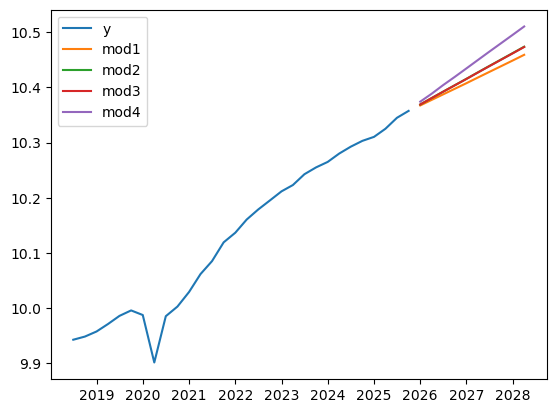

In [30]:
plt.plot(y.tail(30), label='y')
plt.plot(forecasts1, label='mod1')
plt.plot(forecasts2, label='mod2')
plt.plot(forecasts3, label='mod3')
plt.plot(forecasts4, label='mod4')

plt.legend()

plt.show()

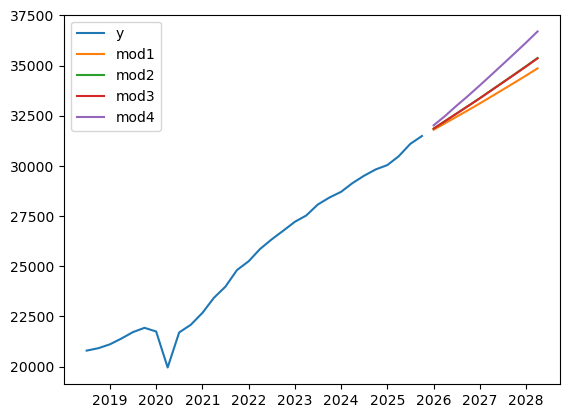

In [37]:
plt.plot(gdp.tail(30), label='y')
plt.plot(np.exp(forecasts1), label='mod1')
plt.plot(np.exp(forecasts2), label='mod2')
plt.plot(np.exp(forecasts3), label='mod3')
plt.plot(np.exp(forecasts4), label='mod4')

plt.legend()

plt.show()

In [38]:
# импорт из библиотеки statsmodels
from sktime.forecasting.arima import StatsModelsARIMA as ARIMA
# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

# Базовые трансформеры
from sktime.transformations.series.boxcox import LogTransformer, BoxCoxTransformer
from sktime.transformations.series.difference import Differencer

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [39]:
y = web.DataReader(name='M2SL', data_source='fred', start='1990-01')
y.index = y.index.to_period(freq='M')

In [40]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe = LogTransformer() * ARIMA(order=(2,1,2), trend='t')

fh = ForecastingHorizon(np.arange(1,11), freq ='M')

y_pred = pipe.fit_predict(y=y, fh=fh)
y_pred

,M2SL
2026-02,22520.714064
2026-03,22611.250614
2026-04,22704.438267
2026-05,22801.383388
2026-06,22900.533003
2026-07,23001.526220
2026-08,23103.892841
2026-09,23207.375290
2026-10,23311.774544
2026-11,23416.959618


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='M2SL'>)

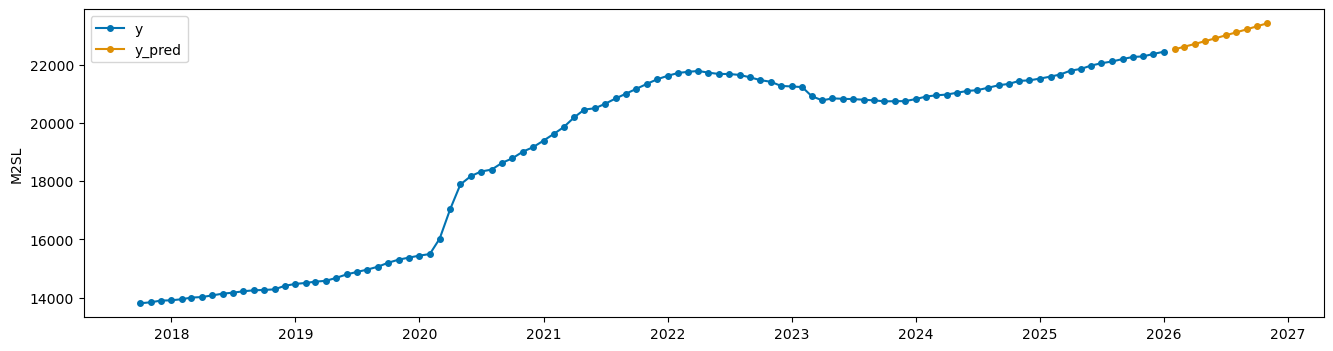

In [42]:
plot_series(y.tail(100), y_pred, labels=['y', 'y_pred'])

In [43]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe = BoxCoxTransformer() * ARIMA(order=(2,1,2), trend='t')

fh = ForecastingHorizon(np.arange(1,11), freq ='M')

y_pred_bc = pipe.fit_predict(y=y, fh=fh)
y_pred_bc

,M2SL
2026-02,22562.960417
2026-03,22684.585286
2026-04,22806.980119
2026-05,22930.150421
2026-06,23054.101838
2026-07,23178.840058
2026-08,23304.370820
2026-09,23430.699907
2026-10,23557.833150
2026-11,23685.776431


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='M2SL'>)

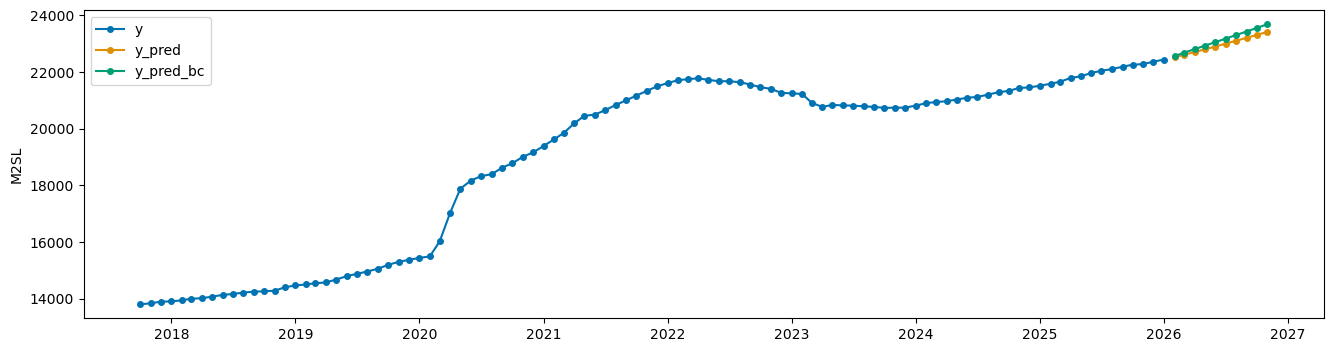

In [46]:
plot_series(y.tail(100), y_pred, y_pred_bc, labels=['y', 'y_pred', 'y_pred_bc'])